# Implementing the Backpropagation Algorithm

A Multilayer Perceptron (MLP) Neural Network trained using the Backpropagation Algorithm on a challenging 8-class dataset. This notebook explores the full pipeline — from data preprocessing and class balancing, through architecture design and mathematical formulation, to iterative hyperparameter tuning and model evaluation.

## Initializing the Libraries

The following libraries are required:

| Library | Purpose |
|---------|--------|
| `numpy` | Numerical operations, matrix math, vectorized computations |
| `matplotlib` | Plotting learning curves and dataset distributions |
| `imblearn` | SMOTE for handling class imbalance (depends on `scipy`) |
| `os`, `csv` | File I/O for loading datasets and exporting results |
| `time` | Tracking training duration |

In [1]:
%pip install numpy matplotlib 
%pip install imblearn imbalanced-learn

#imbalanced learn (dependent on scipy) is neaded for SMOTE.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
!python --version
!pip list | grep -E "imblearn"

Python 3.12.2
imblearn                0.0


# The Dataset

## Loading the Dataset

The dataset is loaded from CSV files in the `dataset/` directory. Features are dense numerical vectors with 2052 dimensions, and labels range from 1 to 8 (8 classes). Labels are one-hot encoded into an `(N, 8)` matrix for the output layer — each row has a `1.0` at the index corresponding to its class.

A separate unlabeled test set is also loaded for final predictions.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os, csv

# loading the data
DATASET     = np.loadtxt(os.path.join("dataset", "data.csv"), delimiter=",")
DATALABELS  = np.loadtxt(os.path.join("dataset", "data_labels.csv"), delimiter=",", dtype=int)
TESTSET     = np.loadtxt(os.path.join("dataset", "test_set.csv"), delimiter=",")

print(f"DATASET : {DATASET.shape}")
print(f"DATALABELS : {DATALABELS.shape}  classes: {np.unique(DATALABELS)}")
print(f"TESTSET : {TESTSET.shape}")

CLASSES = int(np.max(DATALABELS)) #1,2,3,4,5,6,7,8
LABELS = np.zeros((len(DATALABELS), CLASSES), dtype=float) #what class is the data
for _i, label in enumerate(DATALABELS):
    LABELS[_i, int(label) - 1] = 1.0

print(f"LABELS   : {LABELS.shape}")
print(f"Sample   : label {DATALABELS[0]} → {LABELS[0]}")


DATASET : (3486, 354)
DATALABELS : (3486,)  classes: [1 2 3 4 5 6 7 8]
TESTSET : (701, 354)
LABELS   : (3486, 8)
Sample   : label 8 → [0. 0. 0. 0. 0. 0. 0. 1.]


## Dataset Distribution

To observe how balanced or unbalanced the dataset is, a pie chart is generated showing the class distribution.

This is critical — imbalanced data can cause the network to become biased toward the majority class, predicting it disproportionately and ignoring minority classes entirely.

In [4]:

def piechart(datalabels, title='Class Distribution'): #use trainingset labels
    classcounts = np.bincount(datalabels, minlength=9)[1:]
    labels = [f"Class {i}" for i in range(1, len(classcounts) + 1)]

    plt.figure(figsize=(10, 8))
    plt.pie(classcounts, autopct=lambda pct: f'{int(pct/100.*sum(classcounts))}\n({pct:.1f}%)', startangle=90)
    plt.legend(labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title(title)
    plt.axis('equal')
    plt.show()

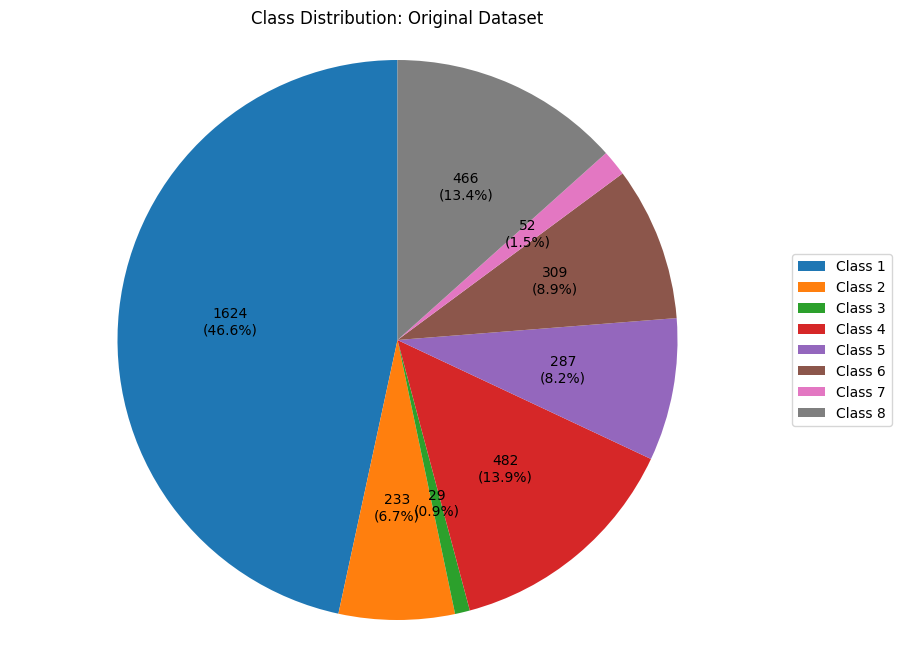

In [5]:
piechart(DATALABELS, "Class Distribution: Original Dataset") #the original

The distribution reveals a significant imbalance. **Class 1 dominates with 46.6%** of the dataset, while **Class 4 holds the smallest share**. This level of skew makes it clear that class balancing is necessary before training — otherwise the network is likely to learn a trivial solution of always predicting the majority class.

## SMOTE (Synthetic Minority Over-sampling Technique)

To address the class imbalance, **SMOTE** is applied to the dataset. SMOTE generates synthetic samples for minority classes by interpolating between existing samples, effectively balancing the class distribution without simply duplicating data points.

In [6]:
X = DATASET
y = DATALABELS

from imblearn.over_sampling import SMOTE

X_balanced, y_balanced = SMOTE(random_state=50).fit_resample(X, y)

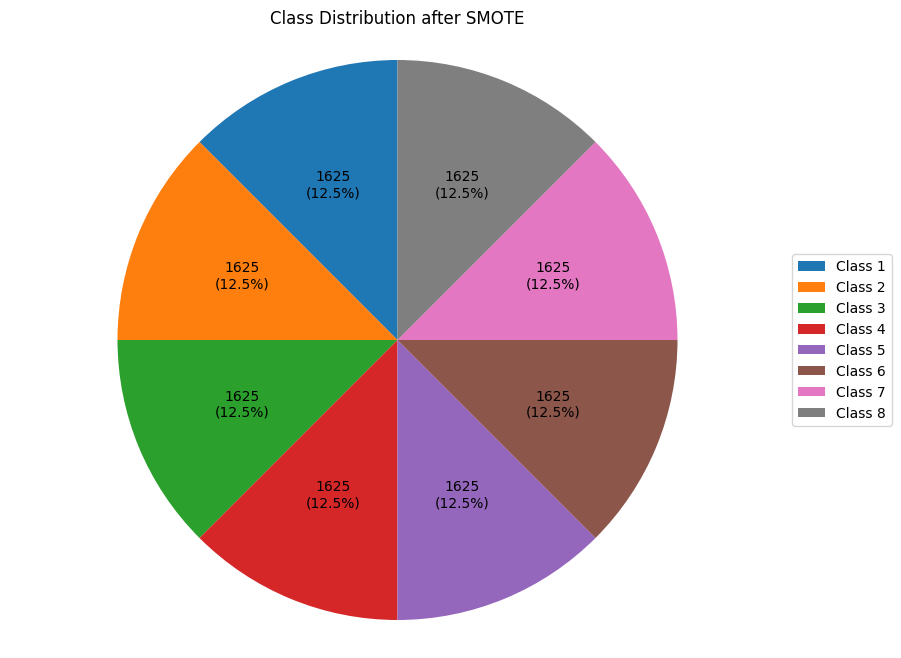

In [7]:
piechart(y_balanced, "Class Distribution after SMOTE")

The dataset is now balanced and ready for training — each class has an equal number of samples, as confirmed by the pie chart.

> **Note on data leakage:** In this implementation, SMOTE was applied *before* splitting into training and validation sets. This means synthetic samples could influence the validation set, potentially leading to optimistic evaluation metrics. Ideally, SMOTE should only be applied to the training fold after the split. This trade-off was accepted for simplicity but is worth noting.

## Partitioning the Dataset

Now that the dataset is balanced and randomized, it is partitioned into training and validation sets using a custom `Partition` class.

- **Validation set:** 800 samples (randomly selected, `random_state=50`)
- **Training set:** remaining samples

The partitions are exported to CSV files (`training_set.csv`, `training_labels.csv`, `validation_set.csv`, `validation_labels.csv`) for reproducibility.

In [8]:
valsize = 800 # fixed validation set size

class Partition: #X is the dataset, y is the datalabels
    def __init__(self, X, y, valsize=800, outputdir="export", randomstate=50):
        os.makedirs(outputdir, exist_ok=True)
        rng = np.random.default_rng(randomstate)

        indices = rng.permutation(len(X))
        validx, trainidx = indices[:valsize], indices[valsize:]

        Xtrain, ytrain = X[trainidx], y[trainidx]
        Xval, yval = X[validx], y[validx]

        self.classes = np.unique(y)
        self.outputdir = outputdir
        self.validationset = Xval
        self.validationlabels = yval
        self.trainingset = Xtrain
        self.traininglabels = ytrain

        self.exportcsv(self.trainingset, "training_set.csv")
        self.exportcsv(self.traininglabels, "training_labels.csv")
        self.exportcsv(self.validationset, "validation_set.csv")
        self.exportcsv(self.validationlabels, "validation_labels.csv")

    def printdetails(self):
        print("Training Set Details")
        print(f"  Shape       : {self.trainingset.shape}")
        print(f"  Label shape : {self.traininglabels.shape}")
        print(f"  Feature min : {self.trainingset.min():.6f}")
        print(f"  Feature max : {self.trainingset.max():.6f}")
        print(f"  Feature mean: {self.trainingset.mean():.6f}")
        # print("\n  Class distribution:")
        # total = len(self.traininglabels)
        # for cls in self.classes:
        #     n = np.sum(self.traininglabels == cls)
        #     print(f"    Class {cls}: {n:>5}  ({n/total*100:.2f}%)")
        piechart(self.traininglabels, "Class Distribution of Training Set")
        print(f"\nValidation Set Details")
        print(f"  Shape       : {self.validationset.shape}")
        print(f"  Label shape : {self.validationlabels.shape}")
        piechart(self.validationlabels, "Class Distribution of Validation Set")

    #all export functions after split
    def exportcsv(self, data, filename):
        path = os.path.join(self.outputdir, filename)
        fmt = "%d" if data.ndim == 1 else "%g"
        np.savetxt(path, data, delimiter=",", fmt=fmt)
        print(f"Saved → {path}  shape: {data.shape}")

Saved → export/training_set.csv  shape: (12200, 354)
Saved → export/training_labels.csv  shape: (12200,)
Saved → export/validation_set.csv  shape: (800, 354)
Saved → export/validation_labels.csv  shape: (800,)
Training Set Details
  Shape       : (12200, 354)
  Label shape : (12200,)
  Feature min : 0.000000
  Feature max : 0.999990
  Feature mean: 0.040234


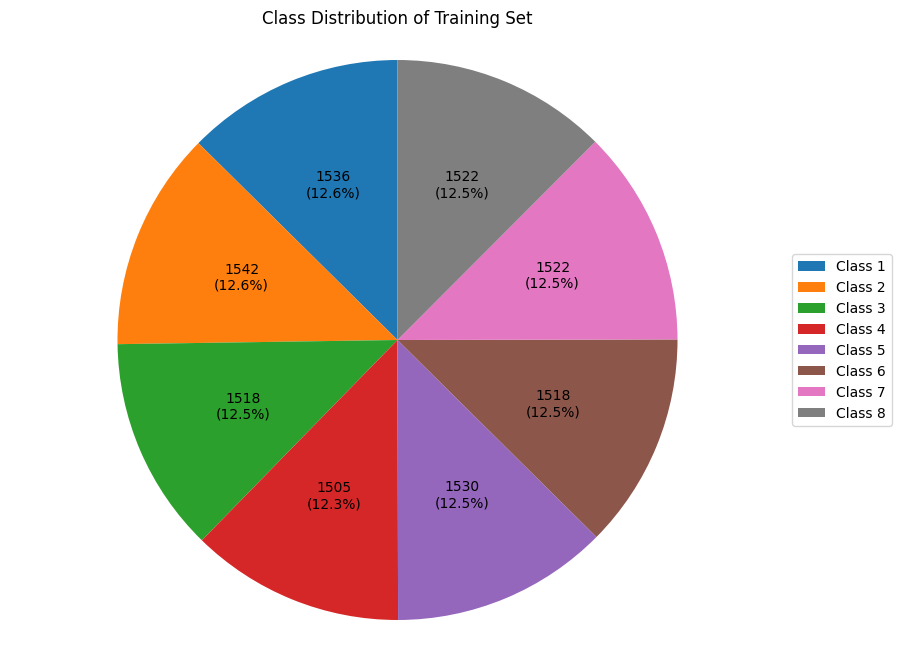


Validation Set Details
  Shape       : (800, 354)
  Label shape : (800,)


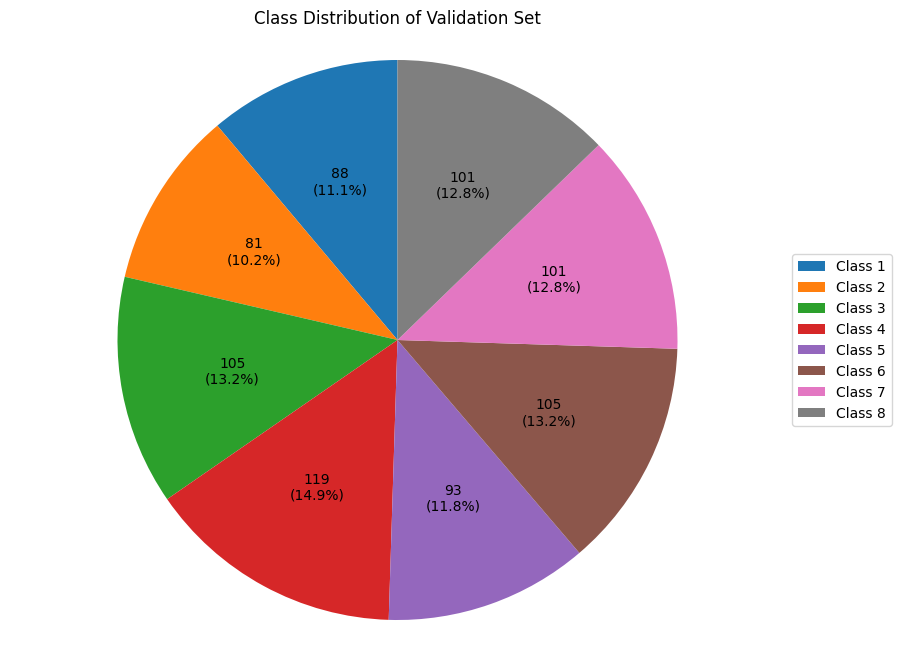

In [9]:
split = Partition(X_balanced, y_balanced)
split.printdetails()

## Batch Size

Mini-batch gradient descent is used with a **batch size of 8**. A generator function `minibatch()` yields sequential slices of the training set and labels for each batch iteration. This allows vectorized computation within each batch while still updating weights multiple times per epoch.

In [10]:
def minibatch(trainingset, traininglabels, batch_size=8):
    N = len(trainingset)
    indices = np.arange(N)
    for start in range(0, N, batch_size):
        i = indices[start : start + batch_size]
        yield trainingset[i], traininglabels[i]

In [11]:
batch_size = 8 #edit this to get the batch size you need
minibatch(split.trainingset, split.traininglabels, batch_size)

<generator object minibatch at 0x127c7c340>

# Setting up the Equations

The backpropagation algorithm is defined by a sequence of mathematical equations that govern forward propagation, error computation, delta calculation, and weight updating. The following sections lay out each equation as implemented in the code.

## Full Equation Reference: Backpropagation Algorithm

> **Notation**
> | Symbol | Meaning |
> |--------|---------|
> | $L$ | Total number of layers (output layer index) |
> | $l$ | Current layer index, $l \in \{1, \dots, L\}$ |
> | $i$ | Index of neuron in layer $l-1$; $i = 0$ is the bias input |
> | $j$ | Index of neuron in layer $l$ |
> | $k$ | Index of neuron in output layer $L$ |
> | $w^{(l)}_{j0}$ | Bias weight of neuron $j$ in layer $l$ (fixed input $\varphi_0 = +1$) |
> | $w^{(l)}_{ji}$ | Weight from neuron $i$ in layer $l-1$ to neuron $j$ in layer $l$ |
> | $v^{(l)}_j$ | Internal activity (pre-activation) of neuron $j$ in layer $l$ |
> | $\varphi_j$ | Activation function of neuron $j$; output $\varphi_j\!\left(v^{(l)}_j\right)$ |
> | $d_k$ | Desired (target) output for output neuron $k$ |
> | $e_k(n)$ | Error at output neuron $k$ at epoch $n$ |
> | $\mathcal{E}(n)$ | Mean square error over all output neurons at epoch $n$ |
> | $\eta$ | Learning rate |
> | $\alpha$ | Momentum coefficient |
> | $a, b$ | Depends on activation function. Used by Logistic and Tanh as constant/s, Leaky ReLU negative-side slope, $\gamma \in (0,1)$ |
> | $n$ | Discrete time step (epoch) |
 
---

## 1. Forward Propagation to get internal activity $v(n)$ and outputs $y_{out}$

### 1.1 Internal Activity
 
The sum begins at $i = 0$ to include the bias weight $w^{(l)}_{j0}$ directly. The bias neuron has a fixed output of $+1$, so $w^{(l)}_{j0} \cdot 1 = w^{(l)}_{j0}$:
 
$$v^{(l)}_j(n) = \sum_{i=0}^{p} w^{(l)}_{ji}(n)\, \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
where $p$ is the number of neurons in layer $l-1$ (excluding the bias), and the bias input is $\varphi_0 = +1$ (constant).
 
### 1.2 Neuron Output
 
$$y_j(n) = \varphi_j\!\left(v^{(l)}_j(n)\right)$$
 
where $\varphi_j$ is the chosen activation function (see Section 2).

## 2. Choosing the Activation Functions
 
Derivatives are expressed in terms of the neuron output $o(n) = \varphi(v(n))$ directly, using constants $a$ and $b$ where applicable.
 
### 2.1 Logistic (Sigmoid)
 
$$\varphi(v) = \frac{1}{1 + e^{-av}}, \quad a > 0$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = a \cdot o(n)\,\bigl(1 - o(n)\bigr)$$

> Given: $a = 2.0$
 
---
 
### 2.2 Hyperbolic Tangent (Tanh)
 
$$\varphi(v) = a \tanh(bv) = a \cdot \frac{e^{bv} - e^{-bv}}{e^{bv} + e^{-bv}}$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = \frac{b}{a}\left(a - o(n)\right)\!\left(a + o(n)\right)$$
 
> Given: $a = 1.716,\; b = 0.66667$
 
---
 
### 2.3 Leaky ReLU
 
$$\varphi(v) = \begin{cases} v & \text{if } v > 0 \\ \gamma\, v & \text{if } v \leq 0 \end{cases}, \quad \gamma \in (0,1)$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = \begin{cases} 1 & \text{if } o(n) > 0 \\ \gamma & \text{if } o(n) \leq 0 \end{cases}$$
 
---

In [12]:
# ACTIVATION FUNCTIONS
def logistic(v, a=1.0):
    phi = 1.0 / (1.0 + np.exp(-a * v))
    return phi

def tanh(v, a=1.0, b=1.0):
    phi = a * np.tanh(b * v)
    return phi
 
def leakyrelu(v, gamma=0.01):
    phi = np.where(v > 0, v, gamma * v)
    return phi
 
def errorSignal(dk, phiVk):
    return dk - phiVk
 
def meanSquareError(ek):
    return 0.5 * np.dot(ek, ek)

# DERIVATIVES
RELU_CLIP = 5.0 #for relu to converge

def dlogistic(o, a=1.0):
    dphi = a * o * (1.0 - o)
    return dphi
 
def dtanh(o, a=1.0, b=1.0):
    dphi = (b / a) * (a - o) * (a + o)
    return dphi
 
def dleakyrelu(o, gamma=0.01):
    dphi = np.where(o > 0, 1.0, gamma)
    return dphi
 
# DERIVATIVE CALL
def callDerivative(method, o, config):
    if method == 0:
        return dlogistic(o, config['a_l']), None
    elif method == 1:
        return dtanh(o, config['a_tanh'], config['b_tanh']), None
    else:
        return dleakyrelu(o, config['a_relu']), RELU_CLIP
 
# ACTIVATION CALL
def callActivation(method, v, config):
    if method == 0:
        return logistic(v, config['a_l'])
    elif method == 1:
        return tanh(v, config['a_tanh'], config['b_tanh'])
    else:
        return leakyrelu(v, config['a_relu'])

## 3. Error & Mean Square Error
 
### 3.1 Error Signal at Output Neuron $k$
 
$$o_k(n)= s \varphi_k\!\left(v^{(L)}_k(n)\right)$$
 
### 3.2 Mean Square Error
 
$$\mathcal{E}(n) = \frac{1}{2} \sum_{k \in \mathcal{C}} e_k^2(n)$$
 
where $\mathcal{C}$ is the set of output neurons.
 
---

## 4. Backpropagation Delta Equations
 
### 4.1 Output Layer Delta
 
$$\delta^{(L)}_k(n) = e_k(n) \cdot \varphi'\!\left(v^{(L)}_k(n)\right)$$
 
### 4.2 Hidden Layer Delta
 
For layer $l \in \{L-1,\, L-2,\, \dots,\, 1\}$:
 
$$\delta^{(l)}_j(n) = \varphi'\!\left(v^{(l)}_j(n)\right) \cdot \sum_{k}\, \delta^{(l+1)}_k(n)\, w^{(l+1)}_{kj}(n)$$
 
The hidden-layer delta propagates the error signal backward by weighting each upstream delta $\delta^{(l+1)}_k$ by the corresponding weight $w^{(l+1)}_{kj}$ and scaling by the local derivative $\varphi'(v^{(l)}_j)$.
 
---

## 5. Weight Update: Negative Gradient with Momentum
 
All weights $w^{(l)}_{ji}$ include the bias weights at $i = 0$ (with fixed input $\varphi_0 = +1$). No separate bias update is needed.
 
The weight correction follows the **negative gradient** of $\mathcal{E}(n)$ with respect to $w^{(l)}_{ji}$:
 
$$-\frac{\partial \mathcal{E}(n)}{\partial w^{(l)}_{ji}(n)} = \delta^{(l)}_j(n) \cdot \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
### 5.1 Weight Increment (Generalized Delta Rule + Momentum)
 
$$\Delta w^{(l)}_{ji}(n) = \underbrace{\alpha\, \Delta w^{(l)}_{ji}(n-1)}_{\text{momentum}} \;-\; \underbrace{\eta\, \frac{\partial \mathcal{E}(n)}{\partial w^{(l)}_{ji}(n)}}_{\text{negative gradient}}$$
 
Substituting the gradient expression:
 
$$\Delta w^{(l)}_{ji}(n) = \alpha\, \Delta w^{(l)}_{ji}(n-1) \;+\; \eta\, \delta^{(l)}_j(n)\, \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
### 5.2 Weight Update Rule
 
$$w^{(l)}_{ji}(n+1) = w^{(l)}_{ji}(n) + \Delta w^{(l)}_{ji}(n)$$
 
> **Bias weights** ($i = 0$) are updated identically using $\varphi_0 = +1$, so:
> $$\Delta w^{(l)}_{j0}(n) = \alpha\, \Delta w^{(l)}_{j0}(n-1) \;+\; \eta\, \delta^{(l)}_j(n)$$
 
> **Momentum note:** When $\alpha = 0$, this reduces to the standard (vanilla) delta rule. When $\alpha > 0$, the update accumulates a fraction of the previous step, smoothing oscillations and accelerating convergence along consistent gradient directions.
 
---

In [ ]:
class OutputLayer:
    def __init__(self, method, w_old, config, dw_prev=None):
        self.config = config
        self.method = method
        self.v = []
        self.o = []
        self.d = []
        self.w_old = w_old
        self.size = config['size']
        self.delta = []
        self.error = []
        self.mse = 0.0
        self.w_new = []
        self.totaltime = 0
 
        self.dw_prev = dw_prev if dw_prev is not None else np.zeros_like(w_old)
        self.phiIn = None
        self.gradient = np.zeros_like(w_old)
 
    def forward(self, phiIn):
        self.phiIn = phiIn
        self.v = self.w_old @ phiIn
        self.o = callActivation(self.method, self.v, self.config)
 
    def computeError(self, d):
        self.d = np.asarray(d, dtype=float)
        self.error = errorSignal(self.d, self.o)
        self.mse = meanSquareError(self.error)
 
    def computeDelta(self):
        dphi, _ = callDerivative(self.method, self.o, self.config)
        self.delta = self.error * dphi
 
    def accumulateGradient(self):
        self.gradient += np.outer(self.delta, self.phiIn)
 
    def resetGradient(self):
        self.gradient = np.zeros_like(self.w_old)
 
    def updateWeights(self, batch_size=1):
        dw = self.config['alpha'] * self.dw_prev + self.config['eta'] * (self.gradient / batch_size)
        self.w_new = self.w_old + dw
        self.dw_prev = dw
        self.gradient = np.zeros_like(self.w_old)
 
 
class HiddenLayer:
    def __init__(self, method, w_old, config, size=8, dw_prev=None):
        self.config = config
        self.method = method
        self.v = []
        self.y = []
        self.w_old = w_old
        self.size = size
        self.delta = 0.0
        self.w_new = []

        self.dw_prev = dw_prev if dw_prev is not None else np.zeros_like(w_old)
        self.phiIn = None
        self.gradient = np.zeros_like(w_old)
 
    def forward(self, phiIn):
        self.phiIn = phiIn
        self.v = self.w_old @ phiIn
        self.y = callActivation(self.method, self.v, self.config)
        return np.concatenate(([1.0], self.y))
 
    def computeDelta(self, nextLayer):
        dphi, _ = callDerivative(self.method, self.y, self.config)
        w_nobias = nextLayer.w_old[:, 1:]
        propagated = w_nobias.T @ nextLayer.delta
        self.delta = dphi * propagated
 
    def accumulateGradient(self):
        self.gradient += np.outer(self.delta, self.phiIn)
 
    def resetGradient(self):
        self.gradient = np.zeros_like(self.w_old)
 
    def updateWeights(self, batch_size=1):
        dw = self.config['alpha'] * self.dw_prev + self.config['eta'] * (self.gradient / batch_size)
        _, clip = callDerivative(self.method, self.y, self.config)
        if clip is not None:
            norm = np.linalg.norm(dw)
            if norm > clip:
                dw = dw * (clip / norm)
        self.w_new = self.w_old + dw
        self.dw_prev = dw
        self.gradient = np.zeros_like(self.w_old)
        return self.w_new
 
 
class Epoch:
    def __init__(self, split, config):
        self.config = config

        inputsize  = split.trainingset.shape[1] + 1
        hiddensize = config['size']
        outputsize = len(split.classes)
        #randomizing start weights
        Wi = np.random.randn(hiddensize, inputsize) * 0.01
        Wj = np.random.randn(hiddensize, hiddensize + 1)  * 0.01
        Wk = np.random.randn(outputsize, hiddensize + 1)  * 0.01

        self.hiddenlayer_i = HiddenLayer(config['methods'][0], Wi, config, size=hiddensize)
        self.hiddenlayer_j = HiddenLayer(config['methods'][1], Wj, config, size=hiddensize)
        self.outputlayer_k = OutputLayer(config['methods'][2], Wk, config)

        self.test_set = list(zip(split.validationset, split.validationlabels))
        self.error = 0.0 #for scores
        
        self.batch_iteration = 0
        self.epoch_iteration = 0

        #for export
        self.train_errors = []
        self.val_errors = []
        self.epochs_logged = []
        
        self.tp = self.tn = self.fp = self.fn = 0.0
        self.p = self.r = self.a = self.f1 = self.matthews = 0.0

        self.trainingset = split.trainingset
        self.traininglabels = split.traininglabels
 
    def run(self, x, d):
        x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
 
        # Forward Prop
        phi_i = self.hiddenlayer_i.forward(x_biased)
        phi_j = self.hiddenlayer_j.forward(phi_i)
        self.outputlayer_k.forward(phi_j)
 
        outputsize = self.outputlayer_k.w_old.shape[0]
        d_onehot = np.zeros(outputsize)
        d_onehot[int(d) - 1] = 1.0

        # Error calcs
        self.outputlayer_k.computeError(d_onehot)
        self.error = self.outputlayer_k.mse
 
        # Backprop
        self.outputlayer_k.computeDelta()
        self.hiddenlayer_j.computeDelta(self.outputlayer_k)
        self.hiddenlayer_i.computeDelta(self.hiddenlayer_j)
 
        # Accumulate (batch_size=1, so gradient = outer(delta, phiIn))
        self.outputlayer_k.accumulateGradient()
        self.hiddenlayer_j.accumulateGradient()
        self.hiddenlayer_i.accumulateGradient()
 
        # Weight updates
        self.outputlayer_k.updateWeights()
        self.hiddenlayer_j.updateWeights()
        self.hiddenlayer_i.updateWeights()
 
        # Advance w_old → w_new
        self.outputlayer_k.w_old = self.outputlayer_k.w_new
        self.hiddenlayer_j.w_old = self.hiddenlayer_j.w_new
        self.hiddenlayer_i.w_old = self.hiddenlayer_i.w_new
 
        self.epoch_iteration += 1
 
    def run_batch(self, X_batch, D_batch):
        batch_size = len(X_batch)
        error = 0.0
 
        for SAMPLE in range(batch_size):
            x_biased = np.concatenate(([1.0], np.asarray(X_batch[SAMPLE], dtype=float)))
 
            # Forward Prop
            phi_i = self.hiddenlayer_i.forward(x_biased)
            phi_j = self.hiddenlayer_j.forward(phi_i)
            self.outputlayer_k.forward(phi_j)
 
            outputsize = self.outputlayer_k.w_old.shape[0]
            d_onehot = np.zeros(outputsize)
            d_onehot[int(D_batch[SAMPLE]) - 1] = 1.0

            # Error calcs
            self.outputlayer_k.computeError(d_onehot)
            error += self.outputlayer_k.mse
 
            # Backprop
            self.outputlayer_k.computeDelta()
            self.hiddenlayer_j.computeDelta(self.outputlayer_k)
            self.hiddenlayer_i.computeDelta(self.hiddenlayer_j)
 
            # Accumulate
            self.outputlayer_k.accumulateGradient()
            self.hiddenlayer_j.accumulateGradient()
            self.hiddenlayer_i.accumulateGradient()
 
        # Weight updates uses batch_size from config
        self.outputlayer_k.updateWeights(batch_size)
        self.hiddenlayer_j.updateWeights(batch_size)
        self.hiddenlayer_i.updateWeights(batch_size)
 
        # Advance w_old to w_new
        self.outputlayer_k.w_old = self.outputlayer_k.w_new
        self.hiddenlayer_j.w_old = self.hiddenlayer_j.w_new
        self.hiddenlayer_i.w_old = self.hiddenlayer_i.w_new
 
        self.error = error / batch_size
        self.batch_iteration += 1
        return self.error
 
    def Scores(self):
        n_classes = self.outputlayer_k.w_old.shape[0]
        confmat = np.zeros((n_classes, n_classes), dtype=int)
        for x, d in self.test_set:
            x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
            phi_i = self.hiddenlayer_i.forward(x_biased)
            phi_j = self.hiddenlayer_j.forward(phi_i)
            self.outputlayer_k.forward(phi_j)
 
            predicted = np.argmax(self.outputlayer_k.o)
            actual = int(d) - 1   # labels are 1-8; convert to 0-indexed
 
            confmat[actual, predicted] += 1
 
        self.confmat = confmat
        total   = confmat.sum()
        correct = np.trace(confmat)
        self.a  = correct / total if total > 0 else 0.0
 
        # --- Per-class TP, TN, FP, FN and Macro-averaged precision, recall, F1, totaltime ---
        tps, tns, fps, fns = [], [], [], []
        precisions, recalls, f1s = [], [], []
        for c in range(n_classes):
            tp = confmat[c, c]
            fp = confmat[:, c].sum() - tp
            fn = confmat[c, :].sum() - tp
            tn = total - tp - fp - fn
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1   = 2*prec*rec / (prec + rec) if (prec + rec) > 0 else 0.0
            tps.append(int(tp))
            tns.append(int(tn))
            fps.append(int(fp))
            fns.append(int(fn))
            precisions.append(prec)
            recalls.append(rec)
            f1s.append(f1)
        self.tps = tps
        self.tns = tns
        self.fps = fps
        self.fns = fns
        self.precisions = precisions
        self.recalls = recalls
        self.f1s = f1s
        self.p  = np.mean(precisions)
        self.r  = np.mean(recalls)
        self.f1 = np.mean(f1s)

        # Matthews Correlation Coefficient (multiclass)
        tk = confmat.sum(axis=0)
        pk = confmat.sum(axis=1)
        c_total = confmat.sum()
        c_correct = np.trace(confmat)
        cov_yy = c_total * c_correct - np.dot(tk, pk)
        cov_xx = c_total**2 - np.dot(tk, tk)
        cov_yy_denom = c_total**2 - np.dot(pk, pk)
        denom = np.sqrt(float(cov_xx) * float(cov_yy_denom))
        self.matthews = float(cov_yy) / denom if denom > 0 else 0.0
 
    def printConfusionMatrix(self):
        n = self.confmat.shape[0]
        print("Confusion Matrix (rows=Actual, cols=Predicted):")
        header = "      " + "  ".join(f"P{i+1:>2}" for i in range(n))
        print(header)
        for i in range(n):
            row = "  ".join(f"{self.confmat[i, j]:>4}" for j in range(n))
            print(f"A{i+1:>2} | {row}")
 
    def printScores(self):
        self.printConfusionMatrix()
        n = self.confmat.shape[0]
        print()
        print("Per-Class Metrics:")
        print(f"  {'Class':<8} {'TP':>6} {'TN':>6} {'FP':>6} {'FN':>6} {'Precision':>10} {'Recall':>10} {'F1 Score':>10}")
        print(f"  {'-'*8} {'-'*6} {'-'*6} {'-'*6} {'-'*6} {'-'*10} {'-'*10} {'-'*10}")
        for c in range(n):
            print(f"  {'Class '+str(c+1):<8} {self.tps[c]:>6} {self.tns[c]:>6} {self.fps[c]:>6} {self.fns[c]:>6} {self.precisions[c]:>10.5f} {self.recalls[c]:>10.5f} {self.f1s[c]:>10.5f}")
        print()
        print("Summary Metrics:")
        print(f"  Error (MSE):                  {self.error:.5f}")
        print(f"  Accuracy:                     {self.a:.5f}")
        print(f"  Precision (Macro-Avg):        {self.p:.5f}")
        print(f"  Recall (Macro-Avg):           {self.r:.5f}")
        print(f"  F1 Score (Macro-Avg):         {self.f1:.5f}")
        print(f"  Matthews Correlation Coeff:   {self.matthews:.5f}")
 
    def log_epoch(self, epoch_idx, train_error, val_error):
        self.epochs_logged.append(epoch_idx)
        self.train_errors.append(train_error)
        self.val_errors.append(val_error)

    def exportErrors(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        filepath = os.path.join(outputdir, "errors.csv")

        with open(filepath, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['epoch', 'train_error', 'val_error'])

            for ep, tr, val in zip(self.epochs_logged, self.train_errors, self.val_errors):
                writer.writerow([ep, tr, val])
 
    def exportScores(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        filepath = os.path.join(outputdir, "scores.csv")
        writeHeader = not os.path.exists(filepath) or os.path.getsize(filepath) == 0
        n = self.confmat.shape[0]
        with open(filepath, 'w', newline='') as f:
            writer = csv.writer(f)
            if writeHeader:
                header = ['Epoch']
                for c in range(n):
                    cn = f"class{c+1}"
                    header.extend([f"{cn}_TP", f"{cn}_TN", f"{cn}_FP", f"{cn}_FN",
                                f"{cn}_Precision", f"{cn}_Recall", f"{cn}_F1"])
                header.extend(['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'matthews', "Time"])
                writer.writerow(header)
            row = [self.epoch_iteration]
            for c in range(n):
                row.extend([self.tps[c], self.tns[c], self.fps[c], self.fns[c],
                            self.precisions[c], self.recalls[c], self.f1s[c]])
            row.extend([self.a, self.p, self.r, self.f1, self.matthews, self.totaltime])
            writer.writerow(row)

    def exportConfusionMatrix(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        filepath = os.path.join(outputdir, "confusion_matrix.csv")
        np.savetxt(filepath, self.confmat, delimiter=",", fmt="%d")
        print(f"Saved → {filepath}  shape: {self.confmat.shape}")

    def exportWeights(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        weights = [
            (self.hiddenlayer_i.w_old, "Wi"),
            (self.hiddenlayer_j.w_old, "Wj"),
            (self.outputlayer_k.w_old, "Wk"),
        ]
        path = os.path.join(outputdir, "trained_weights.csv")
        with open(path, "w", newline="") as f:
            writer = csv.writer(f)
            for data, label in weights:
                writer.writerow([label])
                if data.ndim == 1:
                    writer.writerow(data.astype(int))
                else:
                    for row in data:
                        writer.writerow(row)
                writer.writerow([])
        print(f"Saved → {path}")

    def exportAll(self, outputdir="export"):
        self.exportErrors(outputdir)
        self.exportScores(outputdir)
        self.exportConfusionMatrix(outputdir)
        self.exportWeights(outputdir)


# Training Phase

With the equations implemented in the `HiddenLayer`, `OutputLayer`, and `Epoch` classes, the training phase can begin. Each training run processes the dataset in mini-batches, computes training and validation errors per epoch, and prints progress every 5 epochs.

## Hyperparameters Setup

Two network configurations are defined below, differing primarily in their activation functions:

| Parameter | Network A (Tanh) | Network B (Leaky ReLU) |
|-----------|-------------------|------------------------|
| Hidden activation | Tanh ($a=1.716, b=2/3$) | Leaky ReLU ($\gamma=0.01$) |
| Output activation | Logistic ($a=1.0$) | Logistic ($a=1.0$) |
| Learning rate ($\eta$) | 0.85 | 0.85 |
| Momentum ($\alpha$) | 0.9 | 0.9 |
| Hidden layer size | 8 | 8 |
| Batch size | 8 | 8 |

The architecture uses **two hidden layers** (layers $i$ and $j$) plus an **output layer** ($k$), with 8 output neurons for 8 classes.

In [14]:
#hyperparameters updated
NetworkA = {
        'methods'    : [1, 1, 0],  # [i, j, k] — 0 logistic, 1 tanh, 2 relu
        'a_l'        : 1.0,        # logistic slope
        'a_tanh'     : 1.716,      # tanh a
        'b_tanh'     : 0.66666,    # tanh b
        'a_relu'     : 0.01,       # leaky relu gamma
        'eta'        : 0.85,       # learning rate
        'alpha'      : 0.9,        # momentum constant
        'size'       : 8,          # hidden layer size
        'batch_size' : 8,          # mini-batch size
    }
NetworkB = {
        'methods'    : [2, 2, 0],  # [i, j, k] — 0 logistic, 1 tanh, 2 relu
        'a_l'        : 1.0,        # logistic slope
        'a_tanh'     : 1.716,      # tanh a
        'b_tanh'     : 0.66666,    # tanh b
        'a_relu'     : 0.01,       # leaky relu gamma
        'eta'        : 0.85,        # learning rate
        'alpha'      : 0.9,        # momentum constant
        'size'       : 8,          # hidden layer size
        'batch_size' : 8,          # mini-batch size
    }
#the main engine:
epochA = Epoch(split, NetworkA)  # layers built inside
epochB = Epoch(split, NetworkB)

## Training: Network A

The training phase begins with Network A using the default hyperparameters. Runtime and error for each training run are printed every 5 epochs.

With the default configuration (`eta=0.85`, `alpha=0.9`, `size=8`), the error remained essentially flat across all 100 epochs. The resulting F1 score was a dismal **0.0324** — the network was effectively guessing a single class. This indicated that the learning rate was too aggressive and the momentum too high, causing weight updates to overshoot.

In [15]:
import time

def computeValError(epoch):
    total_mse = 0.0
    n = len(epoch.test_set)
    for x, d in epoch.test_set:
        x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
        phi_i = epoch.hiddenlayer_i.forward(x_biased)
        phi_j = epoch.hiddenlayer_j.forward(phi_i)
        epoch.outputlayer_k.forward(phi_j)
        n_out = epoch.outputlayer_k.w_old.shape[0]
        d_onehot = np.zeros(n_out)
        d_onehot[int(d) - 1] = 1.0
        epoch.outputlayer_k.computeError(d_onehot)
        total_mse += epoch.outputlayer_k.mse
    return total_mse / n if n > 0 else 0.0

def learningcurve(train_errors, val_errors, networkname="Learning Curve: Training vs Validation Error"):
    epochs = range(1, len(train_errors) + 1)
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_errors, label="Training Error (MSE)")
    plt.plot(epochs, val_errors,   label="Validation Error (MSE)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(networkname)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def train(epoch, networkname = "Learning Curve: Training vs Validation Error", epochs=100):
    batch_size   = epoch.config.get('batch_size', 8)

    totaltime = 0
    for ep in range(epochs):
        start = time.time()
        epoch_error = 0.0
        n_batches = 0
        for xbatch, dbatch in minibatch(epoch.trainingset, epoch.traininglabels, batch_size):
            epoch_error += epoch.run_batch(xbatch, dbatch)
            n_batches += 1
        epoch_error /= max(n_batches, 1)
        
        epoch.error = epoch_error #updating errors
        epoch.epoch_iteration = ep + 1
        val_error = computeValError(epoch)

        epoch.log_epoch(epoch.epoch_iteration, epoch_error, val_error)

        elapsed = time.time() - start
        totaltime += elapsed
        if (ep + 1) % 5 == 0:
            print(f"Epoch {ep+1:>4}  Train: {epoch_error:.5f}  Val: {val_error:.5f}  Time: {elapsed:.3f}s")
    epoch.totaltime = totaltime
    epoch.Scores()
    epoch.printScores()
    print(f"Total training time: {totaltime:.2f}s")
    learningcurve(epoch.train_errors, epoch.val_errors, networkname)

Epoch    5  Train: 0.49820  Val: 0.49998  Time: 0.382s
Epoch   10  Train: 0.50000  Val: 0.50000  Time: 0.380s
Epoch   15  Train: 0.50000  Val: 0.50000  Time: 0.378s
Epoch   20  Train: 0.49941  Val: 0.50000  Time: 0.377s
Epoch   25  Train: 0.50000  Val: 0.50000  Time: 0.376s
Epoch   30  Train: 0.50000  Val: 0.50000  Time: 0.377s
Epoch   35  Train: 0.50000  Val: 0.50000  Time: 0.470s
Epoch   40  Train: 0.50000  Val: 0.50000  Time: 0.379s
Epoch   45  Train: 0.50000  Val: 0.50000  Time: 0.379s
Epoch   50  Train: 0.50000  Val: 0.50000  Time: 0.379s
Epoch   55  Train: 0.50000  Val: 0.50000  Time: 0.383s
Epoch   60  Train: 0.50000  Val: 0.50000  Time: 0.376s
Epoch   65  Train: 0.50000  Val: 0.50000  Time: 0.378s
Epoch   70  Train: 0.50000  Val: 0.50000  Time: 0.378s
Epoch   75  Train: 0.49984  Val: 0.50000  Time: 0.387s
Epoch   80  Train: 0.50000  Val: 0.50000  Time: 0.380s
Epoch   85  Train: 0.49996  Val: 0.50000  Time: 0.395s
Epoch   90  Train: 0.50000  Val: 0.50000  Time: 0.380s
Epoch   95

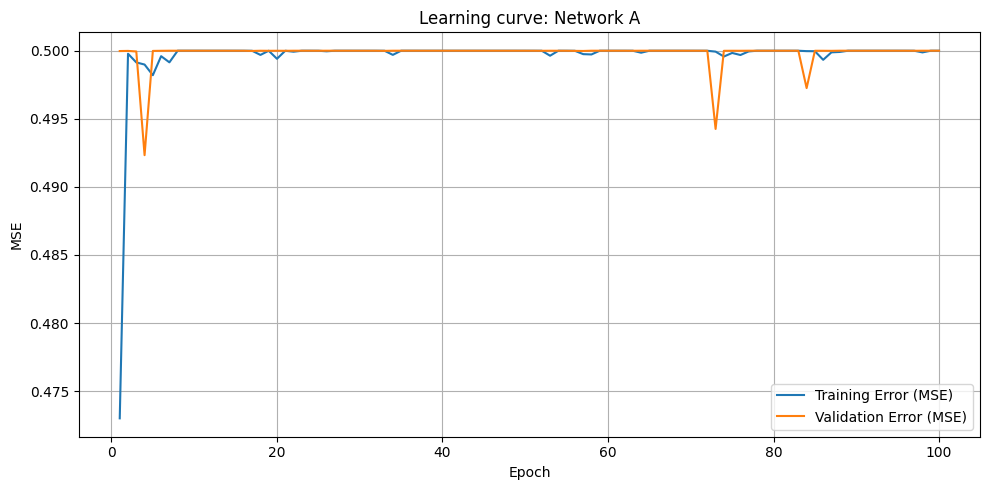

Saved → export/networkA/confusion_matrix.csv  shape: (8, 8)
Saved → export/networkA/trained_weights.csv


In [16]:
train(epochA, "Learning curve: Network A") #network A

epochA.exportAll("export/networkA/")

### Improvements for Network A

Improvements are needed since the error does not converge with the default parameters. The learning rate is lowered from 0.85 to **0.1**, momentum reduced from 0.9 to **0.5**, and hidden layer size increased from 8 to **12**.

These adjustments target the core issue: the original learning rate was too aggressive, causing the weight updates to overshoot the optimal region of the loss surface.

Epoch    5  Train: 0.43746  Val: 0.43677  Time: 0.433s
Epoch   10  Train: 0.22905  Val: 0.19944  Time: 0.440s
Epoch   15  Train: 0.10357  Val: 0.16424  Time: 0.479s
Epoch   20  Train: 0.05839  Val: 0.05818  Time: 0.449s
Epoch   25  Train: 0.04120  Val: 0.03603  Time: 0.478s
Epoch   30  Train: 0.03302  Val: 0.04060  Time: 0.444s
Epoch   35  Train: 0.02799  Val: 0.01964  Time: 0.441s
Epoch   40  Train: 0.02689  Val: 0.05300  Time: 0.434s
Epoch   45  Train: 0.02311  Val: 0.02876  Time: 0.423s
Epoch   50  Train: 0.02230  Val: 0.03049  Time: 0.454s
Epoch   55  Train: 0.02135  Val: 0.01775  Time: 0.450s
Epoch   60  Train: 0.01939  Val: 0.02076  Time: 0.548s
Epoch   65  Train: 0.01774  Val: 0.02883  Time: 0.504s
Epoch   70  Train: 0.01636  Val: 0.02871  Time: 0.454s
Epoch   75  Train: 0.01809  Val: 0.01641  Time: 0.500s
Epoch   80  Train: 0.01522  Val: 0.02589  Time: 0.548s
Epoch   85  Train: 0.01409  Val: 0.01600  Time: 0.473s
Epoch   90  Train: 0.01400  Val: 0.01400  Time: 0.467s
Epoch   95

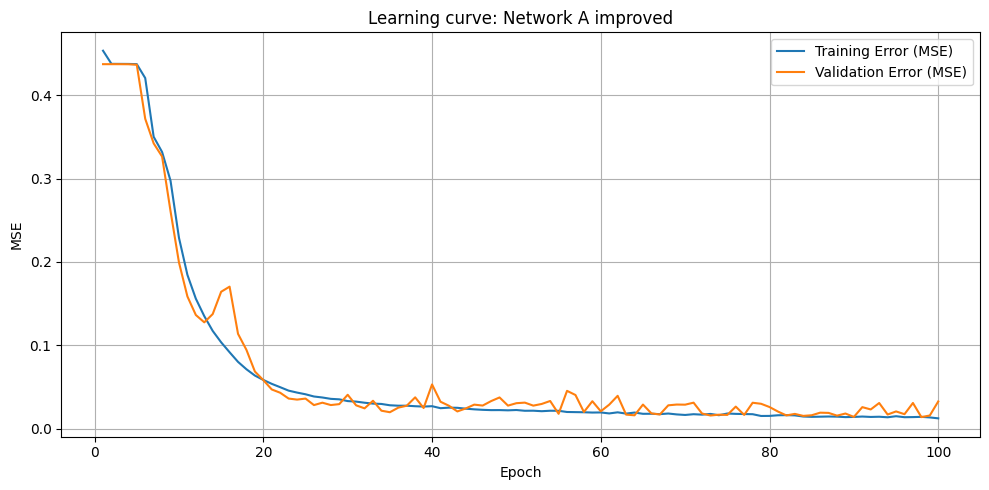

Saved → export/networkA_improv/confusion_matrix.csv  shape: (8, 8)
Saved → export/networkA_improv/trained_weights.csv


In [17]:
NetworkA['eta'] = 0.1 #lowering the learning rate
NetworkA['alpha'] = 0.5 #lowering the momentum
NetworkA['size'] = 12 #increasing the number of hidden layers

epochA_improv = Epoch(split, NetworkA)

train(epochA_improv, "Learning curve: Network A improved")
epochA_improv.exportAll("export/networkA_improv/")

The errors are now converging, and the validation error aligns well with the training error. Training time roughly doubled due to the larger hidden layer (from ~38s to ~43s), but since convergence happened early, training could reasonably be stopped around the **40th epoch**.

The next step is to test whether a slightly smaller hidden layer size of 10 could deliver comparable results faster.

Epoch    5  Train: 0.43765  Val: 0.43726  Time: 0.408s
Epoch   10  Train: 0.26327  Val: 0.22609  Time: 0.404s
Epoch   15  Train: 0.11578  Val: 0.12926  Time: 0.424s
Epoch   20  Train: 0.05910  Val: 0.05681  Time: 0.562s
Epoch   25  Train: 0.03867  Val: 0.03709  Time: 0.467s
Epoch   30  Train: 0.03188  Val: 0.05218  Time: 0.413s
Epoch   35  Train: 0.02629  Val: 0.02649  Time: 0.401s
Epoch   40  Train: 0.02395  Val: 0.03246  Time: 0.453s
Epoch   45  Train: 0.02155  Val: 0.02918  Time: 0.480s
Epoch   50  Train: 0.01848  Val: 0.03236  Time: 0.409s
Epoch   55  Train: 0.01807  Val: 0.01513  Time: 0.436s
Epoch   60  Train: 0.01703  Val: 0.02678  Time: 0.421s
Epoch   65  Train: 0.01515  Val: 0.02121  Time: 0.408s
Epoch   70  Train: 0.01541  Val: 0.03698  Time: 0.406s
Epoch   75  Train: 0.01381  Val: 0.02302  Time: 0.420s
Epoch   80  Train: 0.01205  Val: 0.03348  Time: 0.411s
Epoch   85  Train: 0.01348  Val: 0.01795  Time: 0.407s
Epoch   90  Train: 0.01203  Val: 0.02042  Time: 0.423s
Epoch   95

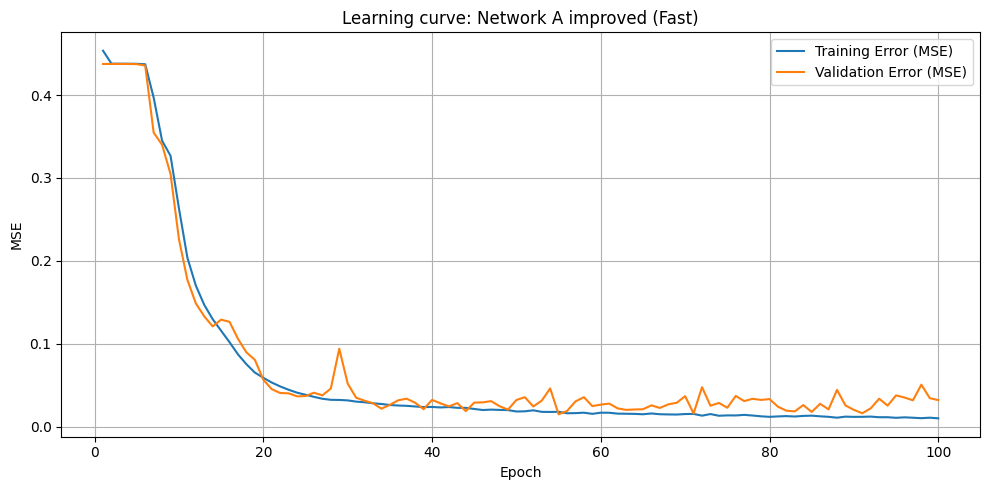

Saved → export/networkA_improv_fast/confusion_matrix.csv  shape: (8, 8)
Saved → export/networkA_improv_fast/trained_weights.csv


In [18]:
NetworkA['alpha'] = 0.5 #increasing the momentum
NetworkA['size'] = 10 #decreasing the number of hidden layers back


epochA_improv_fast = Epoch(split, NetworkA)

train(epochA_improv_fast, "Learning curve: Network A improved (Fast)")
epochA_improv_fast.exportAll("export/networkA_improv_fast/")

Interestingly, having only 10 hidden nodes produced a **lower MSE of 0.00083**, yet it was as fast as the default configuration (~40.8s). This suggests 10 nodes is a sweet spot for this dataset — large enough to capture the decision boundaries, small enough to train efficiently. F1 score: **0.9748**.

## Training: Network B

Network B uses the **Leaky ReLU** function for hidden layers and the **Logistic** function for the output layer. Testing with the default parameters first to establish a baseline.

Epoch    5  Train: 0.44045  Val: 0.43843  Time: 0.469s
Epoch   10  Train: 0.44045  Val: 0.43843  Time: 0.430s
Epoch   15  Train: 0.44045  Val: 0.43843  Time: 0.398s
Epoch   20  Train: 0.44045  Val: 0.43843  Time: 0.417s
Epoch   25  Train: 0.44045  Val: 0.43843  Time: 0.412s
Epoch   30  Train: 0.44045  Val: 0.43843  Time: 0.425s
Epoch   35  Train: 0.44045  Val: 0.43843  Time: 0.420s
Epoch   40  Train: 0.44043  Val: 0.43841  Time: 0.400s
Epoch   45  Train: 0.39645  Val: 0.39454  Time: 0.412s
Epoch   50  Train: 0.39129  Val: 0.39343  Time: 0.448s


/var/folders/ml/vnv07r1j5lq9xn91hby78kkh0000gt/T/ipykernel_31727/621747645.py:3: RuntimeWarning: overflow encountered in exp
  phi = 1.0 / (1.0 + np.exp(-a * v))


Epoch   55  Train: 0.38596  Val: 0.49688  Time: 0.494s
Epoch   60  Train: 0.49742  Val: 0.49687  Time: 0.410s
Epoch   65  Train: 0.49742  Val: 0.49687  Time: 0.401s
Epoch   70  Train: 0.49742  Val: 0.49687  Time: 0.402s
Epoch   75  Train: 0.49742  Val: 0.49687  Time: 0.400s
Epoch   80  Train: 0.49742  Val: 0.49687  Time: 0.399s
Epoch   85  Train: 0.49742  Val: 0.49687  Time: 0.398s
Epoch   90  Train: 0.49742  Val: 0.49687  Time: 0.398s
Epoch   95  Train: 0.49742  Val: 0.49687  Time: 0.397s
Epoch  100  Train: 0.49742  Val: 0.49687  Time: 0.397s
Confusion Matrix (rows=Actual, cols=Predicted):
      P 1  P 2  P 3  P 4  P 5  P 6  P 7  P 8
A 1 |    5    84     0     0     0     0     0     0
A 2 |    0    82     0     0     0     0     0     0
A 3 |    0   106     0     0     0     0     0     0
A 4 |    0   119     0     0     0     0     0     0
A 5 |    0    94     0     0     0     0     0     0
A 6 |    0   106     0     0     0     0     0     0
A 7 |    0   102     0     0     0     

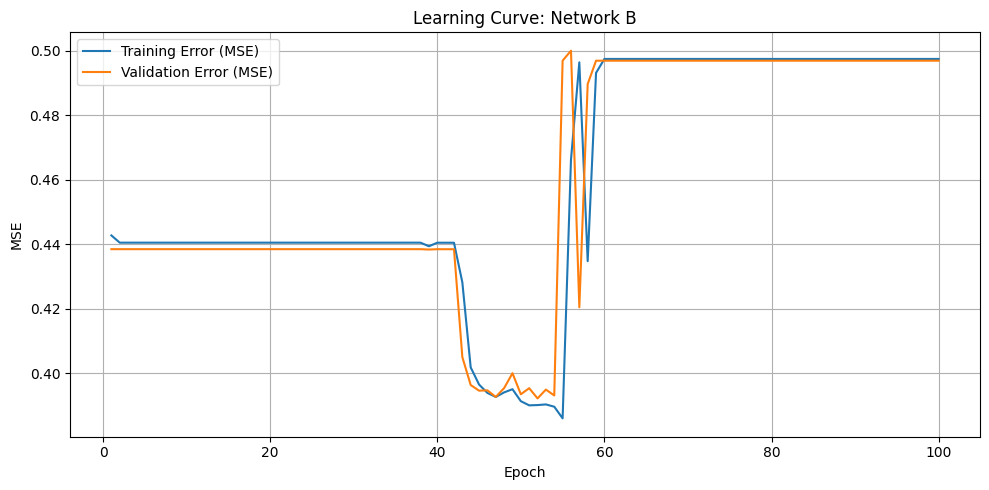

Saved → export/networkB/confusion_matrix.csv  shape: (8, 8)
Saved → export/networkB/trained_weights.csv


In [19]:
train(epochB, "Learning Curve: Network B") #network B
epochB.exportAll("export/networkB/")

## Improvements: Network B

The default learning rate of 0.85 is too high — the errors do not change at all, just as observed with Network A. The same tuning strategy is applied: `eta=0.1`, `alpha=0.5`, `size=10`.

Epoch    5  Train: 0.43767  Val: 0.43742  Time: 0.415s
Epoch   10  Train: 0.34758  Val: 0.33942  Time: 0.445s
Epoch   15  Train: 0.15495  Val: 0.15761  Time: 0.471s
Epoch   20  Train: 0.07500  Val: 0.08383  Time: 0.415s
Epoch   25  Train: 0.05484  Val: 0.08539  Time: 0.522s
Epoch   30  Train: 0.04550  Val: 0.03820  Time: 0.441s
Epoch   35  Train: 0.03966  Val: 0.04010  Time: 0.445s
Epoch   40  Train: 0.03408  Val: 0.04109  Time: 0.423s
Epoch   45  Train: 0.03063  Val: 0.03183  Time: 0.433s
Epoch   50  Train: 0.02963  Val: 0.02739  Time: 0.429s
Epoch   55  Train: 0.02506  Val: 0.02794  Time: 0.423s
Epoch   60  Train: 0.02350  Val: 0.02156  Time: 0.501s
Epoch   65  Train: 0.02193  Val: 0.02701  Time: 0.415s
Epoch   70  Train: 0.01883  Val: 0.03404  Time: 0.413s
Epoch   75  Train: 0.01803  Val: 0.04012  Time: 0.522s
Epoch   80  Train: 0.01782  Val: 0.02085  Time: 0.515s
Epoch   85  Train: 0.01673  Val: 0.01572  Time: 0.429s
Epoch   90  Train: 0.01603  Val: 0.02235  Time: 0.443s
Epoch   95

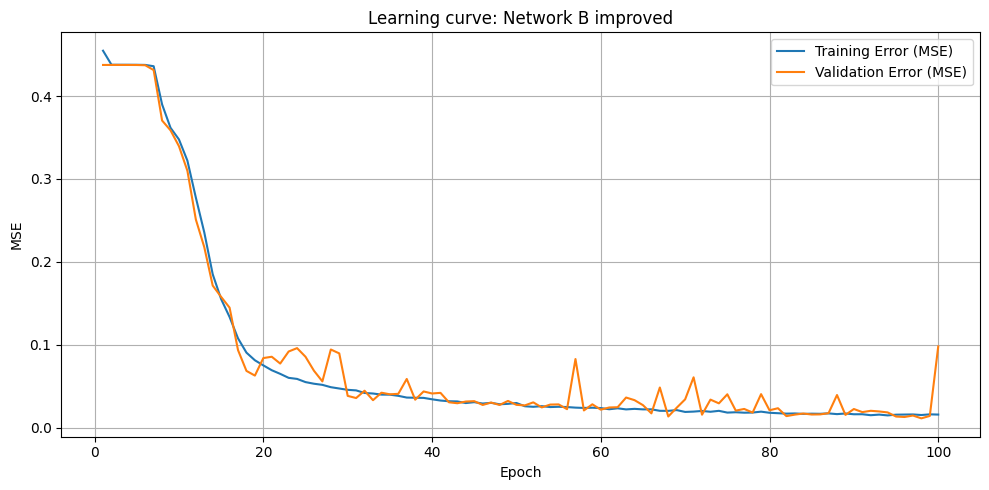

Saved → export/networkB_improv/confusion_matrix.csv  shape: (8, 8)
Saved → export/networkB_improv/trained_weights.csv


In [20]:
NetworkB['eta'] = 0.1 #decreasing the learning rate
NetworkB['alpha'] = 0.5 #decreasing the momentum
NetworkB['size'] = 10 #increasing hidden layer nodes

epochB_improv = Epoch(split, NetworkB)

train(epochB_improv, "Learning curve: Network B improved")
epochB_improv.exportAll("export/networkB_improv/")

# Training Results

After training all network configurations, the results are compiled and ranked by F1 score.

## F1 Score Rankings (summary)

| Rank | network | iteration | f1 score | time |
|---|---|---|---|---|
| 1 | networkB_improv | 152501 | 0.986596 | 43.57 |
| 2 | networkA_improv_fast | 152501 | 0.974757 | 40.83 |
| 3 | networkA_improv | 152501 | 0.974395 | 42.88 |
| 4 | networkA | 152501 | 0.028271 | 38.63 |
| 5 | networkB | 152501 | 0.026286 | 41.89 |

## Full Scores Results

| Rank | network | iteration | accuracy | precision | recall | f1 | matthews | time |
|---|---|---|---|---|---|---|---|---|
| 1 | networkB_improv | 152501 | 0.98625 | 0.98646 | 0.98683 | 0.98660 | 0.98428 | 43.56665 |
| 2 | networkA_improv_fast | 152501 | 0.97500 | 0.97591 | 0.97548 | 0.97476 | 0.97167 | 40.83450 |
| 3 | networkA_improv | 152501 | 0.97375 | 0.97602 | 0.97472 | 0.97439 | 0.97026 | 42.87504 |
| 4 | networkA | 152501 | 0.12750 | 0.01594 | 0.12500 | 0.02827 | 0.00000 | 38.62530 |
| 5 | networkB | 152501 | 0.11750 | 0.01469 | 0.12500 | 0.02629 | 0.00000 | 41.89200 |

**Network B (improved)** with Leaky ReLU is the best training setup with **0.9866 F1 score**. The small time penalty (~43.57s vs ~40.83s) is well worth the performance gain compared to Network A. Its trained weights are exported to `modelA/trained_weights.csv` as the primary model for the unseen test set.

**Network A (improved, fast)** with Tanh is the second-best training setup with a close **0.9748 F1 score**. It loads faster, which would scale better on longer epoch iterations, albeit only slightly. Its weights are exported to `modelB/trained_weights.csv` as the backup model.

The bottom three configurations (all using default hyperparameters) achieved near-zero F1 scores with MCC of 0.0, confirming they learned nothing meaningful.

In [21]:
epochB_improv.exportWeights("modelA/")
epochA_improv_fast.exportWeights("modelB/")

Saved → modelA/trained_weights.csv
Saved → modelB/trained_weights.csv


## Loading the Model

Trained weights are loaded from CSV files using the `loadWeights` function. The function reads the weight matrix, parses the layer dimensions, and returns properly shaped arrays ready for reconstruction.

In [22]:
def loadWeights(path):
    blocks = {'Wi': [], 'Wj': [], 'Wk': []}
    current = None
    with open(path, newline='') as f:
        reader = csv.reader(f)
        for row in reader:
            if not row or row[0].strip() == '':
                continue
            tag = row[0].strip()
            if tag in blocks:
                current = tag
                continue
            if current is not None:
                blocks[current].append([float(v) for v in row])
    return (np.array(blocks['Wi']),
            np.array(blocks['Wj']),
            np.array(blocks['Wk']))

## Running and Exporting the Predictions

The `runPredictions` function takes the loaded weights and test set, reconstructs the network layers, and performs a forward pass for each test sample. Predictions are determined by taking the `argmax` of the output layer activations.

The best two models are used:
- **Network B improved** (Leaky ReLU) → `predictions/networkB_improv_predictions.csv`
- **Network A improved fast** (Tanh) → `predictions/networkA_improv_fast_predictions.csv`

In [23]:
def runPredictions(model, testset, cfg):
    if isinstance(model, tuple):
        Wi, Wj, Wk = model
        layerI = HiddenLayer(cfg['methods'][0], Wi, cfg, size=Wi.shape[0])
        layerJ = HiddenLayer(cfg['methods'][1], Wj, cfg, size=Wj.shape[0])
        layerK = OutputLayer(cfg['methods'][2], Wk, cfg)
    else:
        layerI = model.hiddenlayer_i
        layerJ = model.hiddenlayer_j
        layerK = model.outputlayer_k

    predictions = []
    for x in testset:
        xb   = np.concatenate(([1.0], np.asarray(x, dtype=float)))
        phiI = layerI.forward(xb)
        phiJ = layerJ.forward(phiI)
        layerK.forward(phiJ)
        label = int(np.argmax(layerK.o)) + 1
        predictions.append(label)
    return predictions

def exportPredictions(predictions, filename="predictions_for_test_networkA.csv"):
    outputdir = "predictions"
    os.makedirs(outputdir, exist_ok=True)
    filepath = os.path.join(outputdir, filename)
    with open(filepath, 'w', newline='') as f:
        writer = csv.writer(f)
        for p in predictions:
            writer.writerow([p])
    print(f"Saved {len(predictions)} predictions → {filepath}")

In [24]:
#for sanity's sake, this is the parsed  TESTSET from test_set.csv
print(TESTSET)
print(f"TESTSET : {TESTSET.shape}")

[[2.2071e-02 1.5208e-02 0.0000e+00 ... 4.9787e-03 9.8536e-01 6.6436e-02]
 [2.7050e-02 1.4022e-02 8.7247e-04 ... 2.5246e-02 9.0283e-01 2.7611e-01]
 [4.0489e-02 2.9229e-02 1.7990e-03 ... 1.0859e-02 9.2096e-01 2.6831e-01]
 ...
 [1.6607e-02 2.0379e-02 5.2598e-04 ... 4.4773e-03 9.8416e-01 8.9833e-02]
 [5.6162e-03 5.2749e-03 0.0000e+00 ... 7.8382e-03 9.7868e-01 1.4204e-01]
 [1.1618e-02 1.1367e-02 1.9311e-04 ... 9.4570e-03 8.8809e-01 2.1509e-01]]
TESTSET : (701, 354)


In [25]:
WEIGHTSA = os.path.join("modelA", "trained_weights.csv") #tanh
WEIGHTSB = os.path.join("modelB", "trained_weights.csv") #leakyrelu

MODELA = loadWeights(WEIGHTSA)
MODELB = loadWeights(WEIGHTSB)

predictions_tanh = runPredictions(MODELA, TESTSET, NetworkA)
predictions_relu = runPredictions(MODELB, TESTSET, NetworkB)

#exporting predictions
exportPredictions(predictions_tanh, filename="predictions_for_test_tanh.csv")
exportPredictions(predictions_relu, filename="predictions_for_test_leakyrelu.csv")


Saved 701 predictions → predictions/predictions_for_test_tanh.csv
Saved 701 predictions → predictions/predictions_for_test_leakyrelu.csv


# Conclusion and Recommendations

This project demonstrated the critical importance of **hyperparameter tuning** in neural network training. The default configuration (`eta=0.85`, `alpha=0.9`) failed completely across both architectures, while a simple reduction to `eta=0.1` and `alpha=0.5` transformed the results from near-random guessing (~3% F1) to high-accuracy classification (~98% F1).

**Key takeaways:**

1. **Learning rate dominates early performance.** The default rate of 0.85 was far too aggressive, causing the networks to overshoot and fail to converge. Reducing it to 0.1 was the single most impactful change.

2. **Leaky ReLU outperformed Tanh.** Network B (improved) with Leaky ReLU achieved 0.9866 F1 versus Network A's best of 0.9748. The Leaky ReLU's ability to maintain gradient flow for negative inputs likely contributed to better training dynamics.

3. **Hidden layer size has diminishing returns.** Increasing from 8 to 12 nodes helped convergence, but reducing to 10 nodes actually produced slightly better results with faster training.

4. **Early stopping is recommended.** The learning curves showed convergence around epoch 40 for the improved configurations. Training the full 100 epochs is unnecessary and risks overfitting.

5. **SMOTE effectively addressed class imbalance,** enabling the network to learn meaningful boundaries for all 8 classes. However, applying SMOTE before the train/validation split introduced potential data leakage — a future improvement would be to apply SMOTE only after partitioning.

6. **Momentum should complement, not dominate.** At $\alpha = 0.9$, the momentum term overwhelmed the gradient signal. Reducing to $\alpha = 0.5$ provided enough smoothing without drowning out the gradient.